# Data preparation

In [109]:
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

Brown (2019): https://github.com/IrinaStatsLab/Awesome-CGM/wiki/Brown-(2019)

Quick statistics:

* 168 patients
* no. of recorded events by patient vary from 36,220 to 57,756
* the date range across all patients is from 4.08.2016 to 25.03.2019
* continuous recorded periods for each patient vary from 183 to 204 days with one exeption where one patient had 846 days worth of recorded events

In [110]:
dclp3 = pd.read_csv("C:/Users/meril/Desktop/Projekt_ML/DCLP3/Data Files/cgm.txt", sep="|")

In [111]:
dclp3.head(10)

,PtID,Period,DataDtTm,CGM
0,1,1. Baseline,11DEC17:23:59:25,172
1,1,1. Baseline,12DEC17:00:04:24,170
2,1,1. Baseline,12DEC17:00:09:24,167
3,1,1. Baseline,12DEC17:00:14:25,163
4,1,1. Baseline,12DEC17:00:19:25,160
5,1,1. Baseline,12DEC17:00:24:24,158
6,1,1. Baseline,12DEC17:00:29:25,157
7,1,1. Baseline,12DEC17:00:34:25,155
8,1,1. Baseline,12DEC17:00:39:24,154
9,1,1. Baseline,12DEC17:00:44:25,153


In [112]:
len(dclp3) # 9 032 235

9032235

In [113]:
dclp3['PtID'].value_counts() # sorted in descending order by COUNTS

PtID
119    57756
22     57656
3      57599
169    57555
145    57548
       ...  
45     46170
82     46006
9      44932
127    39300
146    36220
Name: count, Length: 168, dtype: int64

In [114]:
dclp3['PtID'].value_counts().sort_index() # sorted in increasing order by PATIENT ID

PtID
1      57016
2      53537
3      57599
4      48805
5      57151
       ...  
167    55273
168    56066
169    57555
170    46297
171    54984
Name: count, Length: 168, dtype: int64

In [115]:
len(dclp3['PtID'].unique()) # 168 patients

168

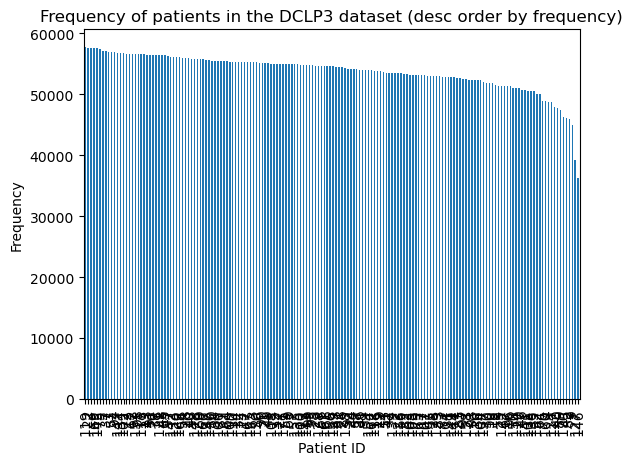

In [116]:
dclp3['PtID'].value_counts().plot(kind='bar')
plt.xlabel('Patient ID')
plt.ylabel('Frequency')
plt.title('Frequency of patients in the DCLP3 dataset (desc order by frequency)')
plt.show()

In [117]:
# Format dates from string to datetime
dclp3['DataDtTm'] = pd.to_datetime(dclp3['DataDtTm'], format='%d%b%y:%H:%M:%S')

In [118]:
dclp3.head()

,PtID,Period,DataDtTm,CGM
0,1,1. Baseline,2017-12-11 23:59:25,172
1,1,1. Baseline,2017-12-12 00:04:24,170
2,1,1. Baseline,2017-12-12 00:09:24,167
3,1,1. Baseline,2017-12-12 00:14:25,163
4,1,1. Baseline,2017-12-12 00:19:25,160


In [119]:
# Extract date from 'DataDtTm' and sort
dclp3['date'] = dclp3['DataDtTm'].dt.date
dclp3 = dclp3.sort_values(['PtID', 'DataDtTm'])
dclp3['date'] = pd.to_datetime(dclp3['date'])

# Extract time from 'DataDtTm' and sort
dclp3['time'] = dclp3['DataDtTm'].dt.time
dclp3['hour'] = dclp3['DataDtTm'].dt.hour
dclp3['minute'] = dclp3['DataDtTm'].dt.minute
# TimeIndex for 24 hours (288 features)
dclp3['TimeIndex'] = dclp3['hour'] * 60 + dclp3['minute']

dclp3 = dclp3.sort_values(['PtID', 'DataDtTm'])

# Calculate the time difference between two events
dclp3['delta_min'] = dclp3.groupby('PtID')['DataDtTm'].diff().dt.total_seconds() / 60

In [120]:
dclp3.head(10)

,PtID,Period,DataDtTm,CGM,date,time,hour,minute,TimeIndex,delta_min
0,1,1. Baseline,2017-12-11 23:59:25,172,2017-12-11,23:59:25,23,59,1439,NaN
1,1,1. Baseline,2017-12-12 00:04:24,170,2017-12-12,00:04:24,0,4,4,4.983333
2,1,1. Baseline,2017-12-12 00:09:24,167,2017-12-12,00:09:24,0,9,9,5.000000
3,1,1. Baseline,2017-12-12 00:14:25,163,2017-12-12,00:14:25,0,14,14,5.016667
4,1,1. Baseline,2017-12-12 00:19:25,160,2017-12-12,00:19:25,0,19,19,5.000000
5,1,1. Baseline,2017-12-12 00:24:24,158,2017-12-12,00:24:24,0,24,24,4.983333
6,1,1. Baseline,2017-12-12 00:29:25,157,2017-12-12,00:29:25,0,29,29,5.016667
7,1,1. Baseline,2017-12-12 00:34:25,155,2017-12-12,00:34:25,0,34,34,5.000000
8,1,1. Baseline,2017-12-12 00:39:24,154,2017-12-12,00:39:24,0,39,39,4.983333
9,1,1. Baseline,2017-12-12 00:44:25,153,2017-12-12,00:44:25,0,44,44,5.016667


In [121]:
min(dclp3["date"])

Timestamp('2016-08-04 00:00:00')

In [122]:
max(dclp3["date"])

Timestamp('2019-03-25 00:00:00')

In [123]:
overview = (
    dclp3.groupby('PtID')['date']
    .agg(start_date='min', end_date='max')
    .reset_index()
)

# Convert to datetime
overview['start_date'] = pd.to_datetime(overview['start_date'])
overview['end_date'] = pd.to_datetime(overview['end_date'])

# Calculate the length of period (days)
overview['period_days'] = (overview['end_date'] - overview['start_date']).dt.days

overview = overview.sort_values(by='period_days', ascending=False)

overview

,PtID,start_date,end_date,period_days
65,68,2016-08-04,2018-11-28,846
106,110,2017-10-12,2018-05-04,204
115,119,2017-10-23,2018-05-15,204
90,94,2018-07-23,2019-02-12,204
20,22,2018-05-15,2018-12-05,204
...,...,...,...,...
154,158,2018-02-22,2018-08-29,188
146,150,2018-01-08,2018-07-15,188
121,125,2018-04-08,2018-10-13,188
73,76,2018-06-08,2018-12-13,188


In [124]:
overview[overview['PtID'].between(1, 5)]
overview[overview['PtID'].isin([1, 5])]

,PtID,start_date,end_date,period_days
0,1,2017-12-11,2018-07-02,203
4,5,2018-01-29,2018-08-20,203


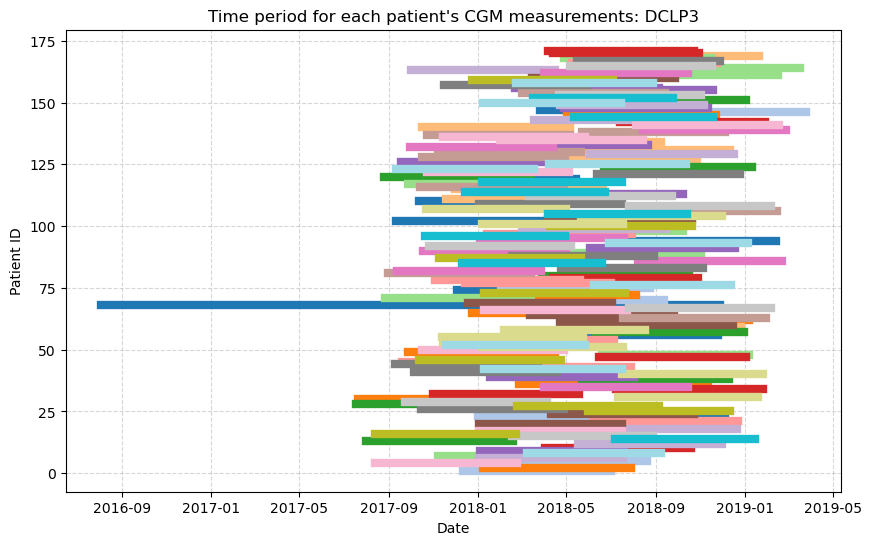

In [125]:
# Plot the range of dates in the data set
overview['start_date'] = pd.to_datetime(overview['start_date'])
overview['end_date'] = pd.to_datetime(overview['end_date'])

plt.figure(figsize=(10,6))

# Set colours for patients so the plots are comparable (look next plt's set of colours)
patients = overview['PtID'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(patients)))
color_map = dict(zip(patients, colors))

# Plot the time periods by patient
for i, row in overview.iterrows():
    plt.plot([row.start_date, row.end_date],
             [row.PtID, row.PtID],
             linewidth=6,
             color=color_map[row.PtID],
             label=row.PtID if i == np.where(patients == row.PtID)[0][0] else None)

plt.xlabel("Date")
plt.ylabel("Patient ID")
plt.title("Time period for each patient's CGM measurements: DCLP3")
plt.grid(True, linestyle='--', alpha=0.5)

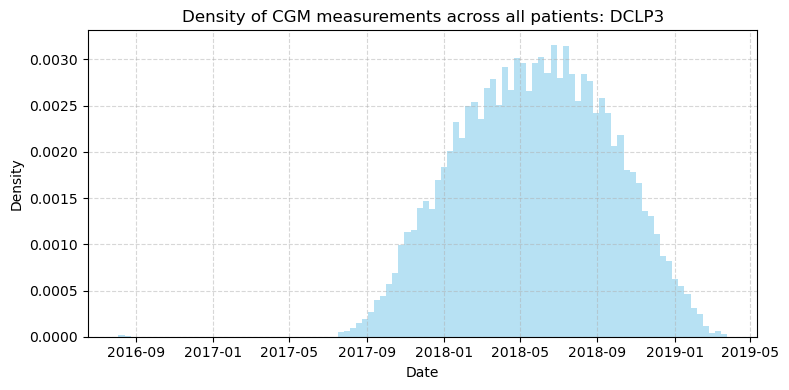

In [126]:
# Histogram of CGM measurements
plt.figure(figsize=(8,4))
plt.hist(dclp3['date'], bins=100, density=True, color='skyblue', alpha=0.6)
plt.title("Density of CGM measurements across all patients: DCLP3")
plt.xlabel("Date")
plt.ylabel("Density")
plt.grid(True, linestyle='--', alpha=0.5)
#plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

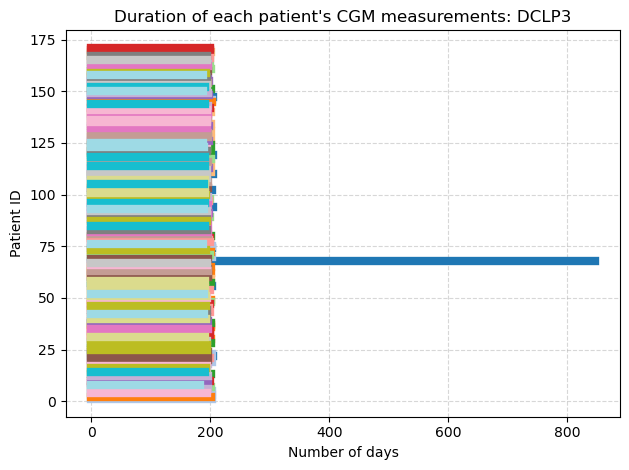

In [128]:
# Plot the durations in the data set
patients = overview['PtID'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(patients)))
color_map = dict(zip(patients, colors))

# Plot each patient
for i, row in overview.iterrows():
    plt.plot(
    [0, row['period_days']],
    [row['PtID'], row['PtID']],
    linewidth=6,
    color=color_map[row['PtID']],
    label=row['PtID'] if i == np.where(patients == row['PtID'])[0][0] else None
)

plt.xlabel("Number of days")
plt.ylabel("Patient ID")
plt.title("Duration of each patient's CGM measurements: DCLP3")
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [130]:
# Deviation of time into 6 standard time periods (given by supervisor)
def assign_period(hour):
    if 0 <= hour < 3:
        return '00:00–03:00'
    elif 3 <= hour < 9:
        return '03:00–09:00'
    elif 9 <= hour < 12:
        return '09:00–12:00'
    elif 12 <= hour < 17:
        return '12:00–17:00'
    elif 17 <= hour < 21:
        return '17:00–21:00'
    else:
        return '21:00–00:00'

In [131]:
dclp3['time_period'] = dclp3['hour'].apply(assign_period)

In [132]:
dclp3.head()

,PtID,Period,DataDtTm,CGM,date,time,hour,minute,TimeIndex,delta_min,time_period
0,1,1. Baseline,2017-12-11 23:59:25,172,2017-12-11,23:59:25,23,59,1439,NaN,21:00–00:00
1,1,1. Baseline,2017-12-12 00:04:24,170,2017-12-12,00:04:24,0,4,4,4.983333,00:00–03:00
2,1,1. Baseline,2017-12-12 00:09:24,167,2017-12-12,00:09:24,0,9,9,5.000000,00:00–03:00
3,1,1. Baseline,2017-12-12 00:14:25,163,2017-12-12,00:14:25,0,14,14,5.016667,00:00–03:00
4,1,1. Baseline,2017-12-12 00:19:25,160,2017-12-12,00:19:25,0,19,19,5.000000,00:00–03:00


In [133]:
# Count missing values at 'CGM'
print("Missing values at column 'CGM': ", dclp3['CGM'].isna().sum())

print("\nSummary of column 'CGM'")
print(dclp3['CGM'].describe())

# If zero -- no need to interpolate

Missing values at column 'CGM':  0

Summary of column 'CGM'
count    9.032235e+06
mean     1.604207e+02
std      6.120771e+01
min      3.900000e+01
25%      1.160000e+02
50%      1.480000e+02
75%      1.930000e+02
max      4.010000e+02
Name: CGM, dtype: float64


In [134]:
# Convert mg/dL → mmol/L, because those are the units our supervisor gave us while giving an overview of the topic
dclp3['CGM_mmol'] = dclp3['CGM'] / 18

# Create a column to check if the value of CGM is between 4–10 mmol/L
dclp3['in_range'] = dclp3['CGM_mmol'].between(4, 10)

# Calculate some statistical stuff
dclp3['CGM_mmol_diff'] = dclp3['CGM_mmol'].diff()
dclp3['rolling_mean_mmol'] = dclp3['CGM_mmol'].rolling(window=4, min_periods=1).mean() # window was given by supervisor
dclp3['rolling_std_mmol'] = dclp3['CGM_mmol'].rolling(window=4, min_periods=1).std()
dclp3['delta_from_mean'] = dclp3['CGM_mmol'] - dclp3['rolling_mean_mmol']

In [135]:
dclp3.head()

,PtID,Period,DataDtTm,CGM,date,time,hour,minute,TimeIndex,delta_min,time_period,CGM_mmol,in_range,CGM_mmol_diff,rolling_mean_mmol,rolling_std_mmol,delta_from_mean
0,1,1. Baseline,2017-12-11 23:59:25,172,2017-12-11,23:59:25,23,59,1439,NaN,21:00–00:00,9.555556,True,NaN,9.555556,NaN,0.000000
1,1,1. Baseline,2017-12-12 00:04:24,170,2017-12-12,00:04:24,0,4,4,4.983333,00:00–03:00,9.444444,True,-0.111111,9.500000,0.078567,-0.055556
2,1,1. Baseline,2017-12-12 00:09:24,167,2017-12-12,00:09:24,0,9,9,5.000000,00:00–03:00,9.277778,True,-0.166667,9.425926,0.139812,-0.148148
3,1,1. Baseline,2017-12-12 00:14:25,163,2017-12-12,00:14:25,0,14,14,5.016667,00:00–03:00,9.055556,True,-0.222222,9.333333,0.217543,-0.277778
4,1,1. Baseline,2017-12-12 00:19:25,160,2017-12-12,00:19:25,0,19,19,5.000000,00:00–03:00,8.888889,True,-0.166667,9.166667,0.244276,-0.277778


In [136]:
# Classify by the CGM_mmol is it in range, hypoglycemia, or hyperglycemia
def classify_glucose(val): # in mmol/L
    if val < 4.0:
        return 'hypoglycemia'
    elif val <= 10:
        return 'in_range'
    else:
        return 'hyperglycemia'

In [137]:
dclp3['CGM_category'] = dclp3['CGM_mmol'].apply(classify_glucose)

In [138]:
dclp3.tail(10)

,PtID,Period,DataDtTm,CGM,date,time,hour,minute,TimeIndex,delta_min,time_period,CGM_mmol,in_range,CGM_mmol_diff,rolling_mean_mmol,rolling_std_mmol,delta_from_mean,CGM_category
4292115,171,2. Post Randomization,2018-10-24 08:25:05,160,2018-10-24,08:25:05,8,25,505,5.000000,03:00–09:00,8.888889,True,0.000000,8.666667,0.290452,0.222222,in_range
4292116,171,2. Post Randomization,2018-10-24 08:30:04,163,2018-10-24,08:30:04,8,30,510,4.983333,03:00–09:00,9.055556,True,0.166667,8.861111,0.184257,0.194444,in_range
4292117,171,2. Post Randomization,2018-10-24 08:35:04,164,2018-10-24,08:35:04,8,35,515,5.000000,03:00–09:00,9.111111,True,0.055556,8.986111,0.114531,0.125000,in_range
4292118,171,2. Post Randomization,2018-10-24 08:40:04,167,2018-10-24,08:40:04,8,40,520,5.000000,03:00–09:00,9.277778,True,0.166667,9.083333,0.160375,0.194444,in_range
4292119,171,2. Post Randomization,2018-10-24 08:45:04,168,2018-10-24,08:45:04,8,45,525,5.000000,03:00–09:00,9.333333,True,0.055556,9.194444,0.132249,0.138889,in_range
4292120,171,2. Post Randomization,2018-10-24 08:50:04,174,2018-10-24,08:50:04,8,50,530,5.000000,03:00–09:00,9.666667,True,0.333333,9.347222,0.232958,0.319444,in_range
4292121,171,2. Post Randomization,2018-10-24 08:55:04,192,2018-10-24,08:55:04,8,55,535,5.000000,03:00–09:00,10.666667,False,1.000000,9.736111,0.643702,0.930556,hyperglycemia
4292122,171,2. Post Randomization,2018-10-24 09:00:04,189,2018-10-24,09:00:04,9,0,540,5.000000,09:00–12:00,10.500000,False,-0.166667,10.041667,0.643702,0.458333,hyperglycemia
4292123,171,2. Post Randomization,2018-10-24 09:05:04,183,2018-10-24,09:05:04,9,5,545,5.000000,09:00–12:00,10.166667,False,-0.333333,10.250000,0.440959,-0.083333,hyperglycemia
4292124,171,2. Post Randomization,2018-10-24 09:10:04,175,2018-10-24,09:10:04,9,10,550,5.000000,09:00–12:00,9.722222,True,-0.444444,10.263889,0.416667,-0.541667,in_range


In [139]:
# Assign the names of the weekday to each event -- useful for certain research questions in some clustering
dclp3['weekday_name'] = dclp3['DataDtTm'].dt.day_name()

In [140]:
dclp3.head(10)

,PtID,Period,DataDtTm,CGM,date,time,hour,minute,TimeIndex,delta_min,time_period,CGM_mmol,in_range,CGM_mmol_diff,rolling_mean_mmol,rolling_std_mmol,delta_from_mean,CGM_category,weekday_name
0,1,1. Baseline,2017-12-11 23:59:25,172,2017-12-11,23:59:25,23,59,1439,NaN,21:00–00:00,9.555556,True,NaN,9.555556,NaN,0.000000,in_range,Monday
1,1,1. Baseline,2017-12-12 00:04:24,170,2017-12-12,00:04:24,0,4,4,4.983333,00:00–03:00,9.444444,True,-0.111111,9.500000,0.078567,-0.055556,in_range,Tuesday
2,1,1. Baseline,2017-12-12 00:09:24,167,2017-12-12,00:09:24,0,9,9,5.000000,00:00–03:00,9.277778,True,-0.166667,9.425926,0.139812,-0.148148,in_range,Tuesday
3,1,1. Baseline,2017-12-12 00:14:25,163,2017-12-12,00:14:25,0,14,14,5.016667,00:00–03:00,9.055556,True,-0.222222,9.333333,0.217543,-0.277778,in_range,Tuesday
4,1,1. Baseline,2017-12-12 00:19:25,160,2017-12-12,00:19:25,0,19,19,5.000000,00:00–03:00,8.888889,True,-0.166667,9.166667,0.244276,-0.277778,in_range,Tuesday
5,1,1. Baseline,2017-12-12 00:24:24,158,2017-12-12,00:24:24,0,24,24,4.983333,00:00–03:00,8.777778,True,-0.111111,9.000000,0.217543,-0.222222,in_range,Tuesday
6,1,1. Baseline,2017-12-12 00:29:25,157,2017-12-12,00:29:25,0,29,29,5.016667,00:00–03:00,8.722222,True,-0.055556,8.861111,0.146986,-0.138889,in_range,Tuesday
7,1,1. Baseline,2017-12-12 00:34:25,155,2017-12-12,00:34:25,0,34,34,5.000000,00:00–03:00,8.611111,True,-0.111111,8.750000,0.115648,-0.138889,in_range,Tuesday
8,1,1. Baseline,2017-12-12 00:39:24,154,2017-12-12,00:39:24,0,39,39,4.983333,00:00–03:00,8.555556,True,-0.055556,8.666667,0.101430,-0.111111,in_range,Tuesday
9,1,1. Baseline,2017-12-12 00:44:25,153,2017-12-12,00:44:25,0,44,44,5.016667,00:00–03:00,8.500000,True,-0.055556,8.597222,0.094879,-0.097222,in_range,Tuesday


In [141]:
# Selecting patients by rank
def is_in_range_rank(pt_start, pt_end): # in mmol/L

    for pt in range(pt_start, pt_end+1):
        subset = dclp3[dclp3['PtID'] == pt]
    
        # Time in Range (must be >= 70%)
        TIR = subset['in_range'].mean() * 100
        
        print(f"Patient no. {pt} Time in Range: {TIR:.1f}%")
        if TIR < 70:
            print("Not in range (<70%)\n")
        elif TIR >= 70:
            print("In range (≥70%)!\n")
        else:
            print("Nan\n")

In [142]:
# By selecting specific patients
def is_in_range_select(pts): # in mmol/L; pts is a vector

    for pt in pts:
        subset = dclp3[dclp3['PtID'] == pt]
    
        # Time in Range (must be >= 70%)
        TIR = subset['in_range'].mean() * 100
        
        print(f"Patient no. {pt} Time in Range: {TIR:.1f}%")
        if TIR < 70:
            print("Not in range (<70%)\n")
        elif TIR >= 70:
            print("In range (≥70%)!\n")
        else:
            print("Nan\n")

In [143]:
# IMPORTANT: the blood sugar level should be between 4-10 mmol/L 70% of the time
pt_start = 73
pt_end = 74
is_in_range_rank(pt_start, pt_end)

Patient no. 73 Time in Range: 66.3%
Not in range (<70%)

Patient no. 74 Time in Range: 55.2%
Not in range (<70%)



In [144]:
pts = [0,2,4,6,8,10]
is_in_range_select(pts)

Patient no. 0 Time in Range: nan%
Nan

Patient no. 2 Time in Range: 64.9%
Not in range (<70%)

Patient no. 4 Time in Range: 69.9%
Not in range (<70%)

Patient no. 6 Time in Range: 69.4%
Not in range (<70%)

Patient no. 8 Time in Range: 72.8%
In range (≥70%)!

Patient no. 10 Time in Range: 70.5%
In range (≥70%)!

